# ACC102 Mini Assignment - Track 2: GitHub Data Analysis Project

## Comparative Analysis of Profitability Stability for Two US-Listed Companies (2019-2023)
---

**Student Name:** Xinyi Chen

**Student ID:** 2470617

**Module:** ACC102 – Artificial Intelligence-Driven Data Analytics  

**Track:** Track 2 - GitHub Data Analysis Project

**Submission Date:** 24 April 2026  

---

## Section 1 — Project Overview

This section defines the scope and purpose of this notebook. It states the analytical problem being investigated, identifies the intended user, and specifies the primary data source used throughout the analysis.

**Analytical Problem:** For any two selected US-listed companies, which firm demonstrates stronger profitability and greater profitability stability over the period 2019–2023, based on Return on Equity (ROE) and Net Profit Margin, and what implications does this have for investment analysis?

**Target User:** Business students, junior analysts, or anyone interested in understanding firm performance using publicly available financial data.

**Primary Database:** U.S. Securities and Exchange Commission (SEC) EDGAR official filings, accessed via three public API endpoints:
- `company_tickers` — maps stock tickers to SEC company IDs (CIK numbers)
- `submissions` — retrieves company profile information (name, exchange, industry)
- `companyfacts` — retrieves standardised annual financial figures (revenue, net income, equity, assets)

---


## Section 2 — Environment Setup

This section installs all required third-party Python libraries and imports them into the working environment. It also defines all global constants — including folder paths, SEC API endpoints, approved filing form types, the analysis year range, and the financial concept names used when parsing SEC data.

Three directories are created automatically if they do not already exist:
- `figures/` — stores all chart image files (PNG)
- `data/` — stores Excel backups of SEC data for offline fallback use
- `outputs/` — stores exported CSV result files


In [1]:
# Install all required third-party packages.
# openpyxl is required for reading and writing Excel (.xlsx) files used in the data backup.
import subprocess
import sys

packages = ['pandas', 'matplotlib', 'seaborn', 'numpy', 'openpyxl']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages ready.')

All packages ready.


In [2]:
# Import all required libraries and define global constants used throughout the notebook.
# Folder directories are created here to ensure they exist before any file is written.
import json
import time
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Directory setup
BASE_DIR     = Path.cwd()
FIGURES_DIR  = BASE_DIR / 'figures'   # stores all chart PNG files
DATA_DIR     = BASE_DIR / 'data'      # stores Excel backups (offline dataset)
OUTPUTS_DIR  = BASE_DIR / 'outputs'   # stores exported CSV result files
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# SEC API endpoints 
SEC_TICKER_URL       = 'https://www.sec.gov/files/company_tickers.json'
SEC_SUBMISSIONS_URL  = 'https://data.sec.gov/submissions/CIK{cik}.json'
SEC_COMPANYFACTS_URL = 'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
# SEC requires all API requests to include a User-Agent header identifying the application.
SEC_USER_AGENT       = 'ACC102Track2/1.0 research@example.com'

# Filing filters
ANNUAL_FORMS = {'10-K', '10-K/A', '20-F', '20-F/A', '40-F', '40-F/A'}
YEARS        = [2019, 2020, 2021, 2022, 2023]
COLORS       = ['#0F4C81', '#D95F02']  # Blue for Company A, orange for Company B

# SEC XBRL financial concept names
# Different companies may use different concept names for the same metric.
SEC_CONCEPTS = {
    'Revenue': [
        'RevenueFromContractWithCustomerExcludingAssessedTax',
        'RevenueFromContractWithCustomerIncludingAssessedTax',
        'SalesRevenueNet',
        'Revenues',
    ],
    'Net_Income': ['NetIncomeLoss'],
    'Equity': [
        'StockholdersEquity',
        'StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest',
    ],
    'Assets': ['Assets'],
}

print(f'Figures  directory : {FIGURES_DIR}')
print(f'Data     directory : {DATA_DIR}')
print(f'Outputs  directory : {OUTPUTS_DIR}')


Figures  directory : C:\Users\chenx\Desktop\ACC102 lab\figures
Data     directory : C:\Users\chenx\Desktop\ACC102 lab\data
Outputs  directory : C:\Users\chenx\Desktop\ACC102 lab\outputs


## Section 3 — Data Acquisition

This section defines all functions responsible for retrieving financial data from the SEC EDGAR API. It also implements a dual-source fallback mechanism to ensure the notebook can run even when the SEC server is unreachable.

The data acquisition pipeline works as follows:
1. `normalize_ticker` — cleans and standardises the user-supplied ticker symbol
2. `sec_get_json` — downloads JSON data from a given SEC URL, with automatic retry on failure
3. `get_ticker_cik_map` — fetches the master list of all companies and maps tickers to CIK numbers
4. `pick_annual_values` — extracts the correct annual figure for each year from the raw SEC filing data
5. `fetch_company_financials` — orchestrates the full SEC download for one company and saves an Excel backup
6. `load_local_financials` — reads a previously saved Excel backup from the `data/` folder
7. `fetch_with_fallback` — attempts a live SEC fetch first; if that fails, automatically switches to the local Excel backup in `data/`


In [3]:
# Clean and standardise the user-supplied ticker symbol.
# Removes leading/trailing spaces and converts to uppercase (e.g. ' aapl ' -> 'AAPL').
def normalize_ticker(ticker):
    value = str(ticker).strip().upper()
    if not value:
        raise ValueError('Ticker cannot be empty.')
    return value

In [4]:
# Download and parse a JSON response from a given SEC EDGAR URL.
# Retries up to 3 times with a 2-second delay between attempts to handle
# temporary network errors or SEC server rate limiting.
def sec_get_json(url, retries=3, delay=2):
    last_error = None
    for attempt in range(retries):
        try:
            request = Request(url, headers={'User-Agent': SEC_USER_AGENT})
            with urlopen(request, timeout=120) as response:
                return json.load(response)
        except Exception as exc:
            last_error = exc
            if attempt < retries - 1:
                time.sleep(delay)
    raise last_error

In [5]:
# Fetch the SEC master company list and build a ticker-to-CIK lookup dictionary.
# CIK (Central Index Key) is the unique ID the SEC assigns to every registered company.
def get_ticker_cik_map():
    payload = sec_get_json(SEC_TICKER_URL)
    return {
        entry['ticker'].upper(): str(entry['cik_str']).zfill(10)
        for entry in payload.values()
    }

In [6]:
# Extract the correct annual financial value for each year from raw SEC XBRL data.
def pick_annual_values(us_gaap, concepts, start_year=2019, end_year=2023):
    for concept in concepts:
        concept_block = us_gaap.get(concept)
        if not concept_block:
            continue
        unit_values = concept_block.get('units', {}).get('USD', [])
        selected = {}
        for item in unit_values:
            if item.get('form') not in ANNUAL_FORMS or item.get('fp') != 'FY' or not item.get('end'):
                continue
            year = pd.to_datetime(item['end']).year
            if year < start_year or year > end_year:
                continue
            prev = selected.get(year)
            if prev is None or item.get('filed', '') > prev.get('filed', ''):
                selected[year] = item
        if selected:
            return {year: item['val'] for year, item in selected.items()}
    return {}

In [7]:
# Fetch a full set of annual financial data for one company from SEC EDGAR.
# Calculates Net Profit Margin and ROE from the raw figures, converts values to
# billions of USD for readability, and saves the result as an Excel backup file
# in the data/ folder before returning the data.
def fetch_company_financials(ticker, start_year=2019, end_year=2023,
                              data_dir=DATA_DIR):
    ticker       = normalize_ticker(ticker)
    cik_map      = get_ticker_cik_map()
    if ticker not in cik_map:
        raise ValueError(f'{ticker} not found in SEC ticker directory.')
    cik          = cik_map[ticker]
    submissions  = sec_get_json(SEC_SUBMISSIONS_URL.format(cik=cik))
    companyfacts = sec_get_json(SEC_COMPANYFACTS_URL.format(cik=cik))
    us_gaap      = companyfacts.get('facts', {}).get('us-gaap', {})
    if not us_gaap:
        raise ValueError(f'{ticker} has no usable SEC us-gaap facts.')

    revenue_map = pick_annual_values(us_gaap, SEC_CONCEPTS['Revenue'],    start_year, end_year)
    income_map  = pick_annual_values(us_gaap, SEC_CONCEPTS['Net_Income'], start_year, end_year)
    equity_map  = pick_annual_values(us_gaap, SEC_CONCEPTS['Equity'],     start_year, end_year)
    assets_map  = pick_annual_values(us_gaap, SEC_CONCEPTS['Assets'],     start_year, end_year)

    rows = []
    for year in range(start_year, end_year + 1):
        revenue    = revenue_map.get(year, np.nan)
        net_income = income_map.get(year,  np.nan)
        equity     = equity_map.get(year,  np.nan)
        assets     = assets_map.get(year,  np.nan)
        # Skip years where all three core metrics are missing
        if pd.isna(revenue) and pd.isna(net_income) and pd.isna(equity):
            continue
        npm = (net_income / revenue * 100) if pd.notna(revenue) and revenue != 0 else np.nan
        roe = (net_income / equity  * 100) if pd.notna(equity)  and equity  != 0 else np.nan
        rows.append({
            'Ticker':            ticker,
            'Company':           submissions.get('name', ticker),
            'Sector':            submissions.get('sicDescription', 'Unknown'),
            'Industry':          submissions.get('sicDescription', 'Unknown'),
            'Exchange':          ', '.join(submissions.get('exchanges', []) or ['Unknown']),
            'Year':              year,
            'Revenue_B':         round(revenue    / 1e9, 2) if pd.notna(revenue)    else np.nan,
            'Net_Income_B':      round(net_income / 1e9, 2) if pd.notna(net_income) else np.nan,
            'Equity_B':          round(equity     / 1e9, 2) if pd.notna(equity)     else np.nan,
            'Assets_B':          round(assets     / 1e9, 2) if pd.notna(assets)     else np.nan,
            'Net_Profit_Margin': round(npm, 2) if pd.notna(npm) else np.nan,
            'ROE':               round(roe, 2) if pd.notna(roe) else np.nan,
        })

    company_df = pd.DataFrame(rows)
    if company_df.empty:
        raise ValueError(f'{ticker} has no annual data between {start_year} and {end_year}.')
    company_df = company_df.sort_values('Year').reset_index(drop=True)

    # Save an Excel backup to data/ before returning — must come before return.
    data_path = Path(data_dir) / f'{ticker}_financials_{start_year}_{end_year}.xlsx'
    try:
        company_df.to_excel(data_path, index=False, engine='openpyxl')
        print(f'  [Data] Backup saved: {data_path}')
    except PermissionError:
        print(f'  [Data] Warning: could not write {data_path.name} — file may be open elsewhere.')

    return company_df

In [8]:
# Load a previously saved Excel backup from the data/ folder.
def load_local_financials(ticker, start_year=2019, end_year=2023,
                           data_dir=DATA_DIR):
    ticker     = normalize_ticker(ticker)
    data_path = Path(data_dir) / f'{ticker}_financials_{start_year}_{end_year}.xlsx'
    if not data_path.exists():
        raise FileNotFoundError(
            f'No data backup found for {ticker} at {data_path}.\n'
            f'Please run the notebook with internet access at least once to generate the data file,'
            f' then upload it to the repository.'
        )
    df = pd.read_excel(data_path, engine='openpyxl')
    print(f'  [Data] Loaded data backup: {data_path}')
    return df


In [9]:
# Dual-source data retrieval with automatic fallback.
# Step 1: Attempt a live fetch from SEC EDGAR (most up-to-date data).
#         On success, an Excel backup is saved automatically by fetch_company_financials.
# Step 2: If the SEC fetch fails for any reason (network error, rate limit, server issue),
#         automatically fall back to the local Excel backup in data/.
# Step 3: If neither source is available, raise a descriptive fatal error.
def fetch_with_fallback(ticker, start_year=2019, end_year=2023,
                        data_dir=DATA_DIR):
    ticker = normalize_ticker(ticker)

    # Step 1: Try live SEC fetch
    try:
        print(f'  [SEC]   Fetching {ticker} from SEC EDGAR...')
        df = fetch_company_financials(ticker, start_year=start_year,
                                      end_year=end_year, data_dir=data_dir)
        print(f'  [SEC]   {ticker} fetched successfully.')
        return df
    except Exception as sec_error:
        print(f'  [SEC]   WARNING: Could not fetch {ticker} from SEC EDGAR.')
        print(f'          Reason : {sec_error}')
        print(f'  [Data] Attempting to load data backup for {ticker}...')

    # Step 2: Try local Excel backup
    try:
        df = load_local_financials(ticker, start_year=start_year,
                                   end_year=end_year, data_dir=data_dir)
        print(f'  [Data] {ticker} loaded from data backup successfully.')
        print(f'  [Data] NOTE: Data is from the cached file, not live SEC data.')
        return df
    except FileNotFoundError as cache_error:
        raise RuntimeError(
            f'[FATAL] Cannot obtain data for {ticker}.\n'
            f'  SEC fetch failed  : {sec_error}\n'
            f'  Data backup error : {cache_error}\n'
            f'  Please run the notebook with internet access at least once\n'
            f'  to generate and upload the data backup files.'
        ) from None

## Section 4 — Data Cleaning and Preparation

This section defines the functions that prepare the raw financial data for analysis. It covers three tasks:
1. **Metric calculation** — defines the stability score formula and the revenue CAGR formula used in the summary table
2. **Data cleaning** — removes rows with missing profitability metrics and clips extreme outliers to a valid range
3. **Table construction** — builds the company profile table and the five-year summary statistics table


In [10]:
# Calculate a profitability stability score for a given metric series (e.g. ROE or NPM).
# The score is derived from the coefficient of variation (std / mean):
# a lower coefficient of variation means more stable results and a higher score.
# The maximum score is capped at 10 to prevent extreme values from distorting comparisons.
def stability_score(series):
    clean = series.dropna()
    if len(clean) < 2:
        return np.nan
    mean = clean.mean()
    std  = clean.std()
    if pd.isna(mean) or pd.isna(std) or mean == 0 or std == 0:
        return np.nan
    return min(1 / (std / abs(mean)), 10)


In [11]:
# Calculate the Compound Annual Growth Rate (CAGR) of revenue over the available years.
# CAGR = (end_value / start_value) ^ (1 / number_of_periods) - 1
# Returns NaN if fewer than two valid data points are available or if values are non-positive.
def revenue_cagr(series):
    clean   = series.dropna()
    if len(clean) < 2:
        return np.nan
    start   = clean.iloc[0]
    end     = clean.iloc[-1]
    periods = len(clean) - 1
    if start <= 0 or end <= 0 or periods <= 0:
        return np.nan
    return ((end / start) ** (1 / periods) - 1) * 100


In [12]:
# Remove rows where Net Profit Margin or ROE is missing, as these are the
# two core metrics used throughout the analysis.
# Extreme values are clipped to the range [-300%, +300%] to prevent outliers
# from distorting chart scales or summary statistics.
def clean_financial_data(comparison_df):
    cleaned_df = comparison_df.dropna(subset=['Net_Profit_Margin', 'ROE']).copy()
    for col in ['Net_Profit_Margin', 'ROE']:
        cleaned_df[col] = cleaned_df[col].clip(-300, 300)
    return cleaned_df.sort_values(['Ticker', 'Year']).reset_index(drop=True)


In [13]:
# Build a deduplicated company profile table showing each company's
# ticker, full name, sector, industry, and exchange.
# Each company appears only once regardless of how many years of data are present.
def build_company_profiles(df):
    return (
        df[['Ticker', 'Company', 'Sector', 'Industry', 'Exchange']]
        .drop_duplicates()
        .reset_index(drop=True)
    )


In [14]:
# Build a five-year summary statistics table grouped by company.
# Calculates mean and standard deviation of ROE and Net Profit Margin,
# revenue CAGR, individual stability scores, and a composite stability score
# (average of NPM stability and ROE stability).
def build_summary_table(df):
    summary_df = (
        df.groupby(['Ticker', 'Company', 'Sector', 'Industry', 'Exchange'], dropna=False)
        .agg(
            Years            = ('Year',              'count'),
            Mean_Revenue_B   = ('Revenue_B',         'mean'),
            Mean_Net_Income_B= ('Net_Income_B',      'mean'),
            Mean_Equity_B    = ('Equity_B',          'mean'),
            Mean_NPM         = ('Net_Profit_Margin', 'mean'),
            Std_NPM          = ('Net_Profit_Margin', 'std'),
            Mean_ROE         = ('ROE',               'mean'),
            Std_ROE          = ('ROE',               'std'),
            Revenue_CAGR     = ('Revenue_B',         revenue_cagr),
            NPM_Stability    = ('Net_Profit_Margin', stability_score),
            ROE_Stability    = ('ROE',               stability_score),
        )
        .reset_index()
    )
    # Composite stability is the average of NPM and ROE stability scores
    summary_df['Composite_Stability'] = summary_df[['NPM_Stability', 'ROE_Stability']].mean(axis=1)
    return summary_df.round(2)


## Section 5 — Analysis and Visualisation

This section defines all chart-generating functions. Eight figures are produced in total, covering five dimensions of financial comparison:
- **Trend line charts (Figures 1–5):** show how Revenue, Net Income, Equity, ROE, and Net Profit Margin changed annually from 2019 to 2023 for both companies
- **Trajectory scatter chart (Figure 6):** plots ROE against Net Profit Margin year by year, revealing each company's combined profitability path over time
- **Heatmap (Figure 7):** displays ROE and Net Profit Margin values as a colour-coded grid, making year-on-year patterns immediately visible
- **Summary bar charts (Figure 8):** compares five-year average ROE, average NPM, Revenue CAGR, and Composite Stability side by side

All figures are saved as PNG files to the `figures/` directory.


In [15]:
# Save a matplotlib figure to the figures/ directory and record the file path.
def save_chart(fig, figures_dir, filename, generated_charts, show=True):
    path = figures_dir / filename
    fig.savefig(path, bbox_inches='tight')
    generated_charts.append(str(path))
    if show:
        plt.show()
    plt.close(fig)


In [16]:
# Draw a dual-line time-series chart for any single financial metric.
# Each company is represented by a distinct colour line with circle markers.
# A horizontal reference line at zero is added for metrics that can go negative
# (Net Income, ROE, Net Profit Margin) to aid interpretation.
def plot_metric_line_chart(df, metric, ylabel, title, figures_dir,
                            filename, generated_charts, show=True):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for idx, (ticker, sub) in enumerate(df.groupby('Ticker', sort=False)):
        ordered = sub.sort_values('Year')
        ax.plot(ordered['Year'], ordered[metric], marker='o', linewidth=2.3,
                color=COLORS[idx], label=f"{ticker} ({ordered['Company'].iloc[0]})")
    if metric in ['Net_Income_B', 'ROE', 'Net_Profit_Margin']:
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    plt.tight_layout()
    save_chart(fig, figures_dir, filename, generated_charts, show=show)


In [17]:
# Draw a scatter chart plotting ROE (y-axis) against Net Profit Margin (x-axis).
# Each point represents one fiscal year, labelled with the year number.
# The path traced by the points shows how each company's combined profitability
# position shifted over the five-year period.
def plot_profitability_trajectory(df, figures_dir, filename, generated_charts, show=True):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    for idx, (ticker, sub) in enumerate(df.groupby('Ticker', sort=False)):
        ordered = sub.sort_values('Year')
        ax.plot(ordered['Net_Profit_Margin'], ordered['ROE'], marker='o',
                linewidth=2, color=COLORS[idx], label=ticker)
        for _, row in ordered.iterrows():
            ax.annotate(str(int(row['Year'])),
                        (row['Net_Profit_Margin'], row['ROE']),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title('Profitability Trajectory: ROE vs Net Profit Margin',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Net Profit Margin (%)')
    ax.set_ylabel('ROE (%)')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    save_chart(fig, figures_dir, filename, generated_charts, show=show)


In [18]:
# Draw a side-by-side heatmap showing ROE and Net Profit Margin by company and year.
# Green cells indicate stronger positive performance; red cells indicate weaker or
# negative performance. This makes year-on-year patterns immediately visible.
def plot_profitability_heatmap(df, figures_dir, filename, generated_charts, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for ax, metric, title in zip(
        axes,
        ['ROE', 'Net_Profit_Margin'],
        ['ROE Heatmap (%)', 'Net Profit Margin Heatmap (%)'],
    ):
        pivot = (
            df.assign(Label=lambda x: x['Ticker'] + ' | ' + x['Company'])
            .pivot(index='Label', columns='Year', values=metric)
            .reindex(columns=YEARS)
        )
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                    linewidths=0.5, ax=ax, cbar=(ax is axes[-1]))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('')
    plt.tight_layout()
    save_chart(fig, figures_dir, filename, generated_charts, show=show)


In [19]:
# Draw a 2x2 grid of bar charts comparing four five-year summary metrics:
# Mean ROE, Mean Net Profit Margin, Revenue CAGR, and Composite Stability Score.
# Each metric is shown as a pair of bars, one per company, with the value labelled above.
def plot_summary_bars(summary_df, figures_dir, filename, generated_charts, show=True):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.flatten()
    metrics = [
        ('Mean_ROE',             'Mean ROE (%)'),
        ('Mean_NPM',             'Mean Net Profit Margin (%)'),
        ('Revenue_CAGR',         'Revenue CAGR (%)'),
        ('Composite_Stability',  'Composite Stability Score'),
    ]
    for ax, (metric, label) in zip(axes, metrics):
        values = summary_df[metric].fillna(0)
        ax.bar(summary_df['Ticker'], values, color=COLORS[:len(summary_df)])
        for ticker, value in zip(summary_df['Ticker'], values):
            ax.text(ticker, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.25)
    fig.suptitle('Five-Year Comparison Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_chart(fig, figures_dir, filename, generated_charts, show=show)


In [20]:
# Call all eight chart functions in sequence and return the list of saved file paths.
# Charts are named systematically: fig_track2_{number}_{tickerA}_{tickerB}_{metric}.png
def generate_all_charts(df, summary_df, ticker_a, ticker_b, figures_dir, show=True):
    generated_charts = []
    plot_metric_line_chart(df, 'Revenue_B',         'Revenue (USD bn)',
        'Revenue Trend (2019-2023)',
        figures_dir, f'fig_track2_1_{ticker_a}_{ticker_b}_revenue.png',    generated_charts, show=show)
    plot_metric_line_chart(df, 'Net_Income_B',      'Net Income (USD bn)',
        'Net Income Trend (2019-2023)',
        figures_dir, f'fig_track2_2_{ticker_a}_{ticker_b}_net_income.png', generated_charts, show=show)
    plot_metric_line_chart(df, 'Equity_B',          'Equity (USD bn)',
        "Shareholders' Equity Trend (2019-2023)",
        figures_dir, f'fig_track2_3_{ticker_a}_{ticker_b}_equity.png',     generated_charts, show=show)
    plot_metric_line_chart(df, 'ROE',               'ROE (%)',
        'Return on Equity (ROE) Trend (2019-2023)',
        figures_dir, f'fig_track2_4_{ticker_a}_{ticker_b}_roe.png',        generated_charts, show=show)
    plot_metric_line_chart(df, 'Net_Profit_Margin', 'Net Profit Margin (%)',
        'Net Profit Margin Trend (2019-2023)',
        figures_dir, f'fig_track2_5_{ticker_a}_{ticker_b}_npm.png',        generated_charts, show=show)
    plot_profitability_trajectory(
        df, figures_dir, f'fig_track2_6_{ticker_a}_{ticker_b}_trajectory.png', generated_charts, show=show)
    plot_profitability_heatmap(
        df, figures_dir, f'fig_track2_7_{ticker_a}_{ticker_b}_heatmap.png',    generated_charts, show=show)
    plot_summary_bars(
        summary_df, figures_dir, f'fig_track2_8_{ticker_a}_{ticker_b}_summary.png', generated_charts, show=show)
    return generated_charts


## Section 6 — Key Findings and Interpretation

This section defines the function that automatically generates a written interpretation of the analysis results. It identifies which company leads on average profitability (by mean ROE) and which leads on consistency (by Composite Stability Score), and provides two additional investment-relevant observations about how to read the results together.


In [21]:
# Automatically generate four written findings from the summary statistics table.
# Finding 1 identifies the company with the higher mean ROE (profitability winner).
# Finding 2 identifies the company with the higher composite stability score.
# Findings 3 and 4 provide interpretive guidance for reading the results.
def build_findings(summary_df):
    best_profit    = summary_df.sort_values('Mean_ROE',             ascending=False).iloc[0]
    best_stability = summary_df.sort_values('Composite_Stability',  ascending=False).iloc[0]
    return [
        f"1. Higher average profitability (ROE): {best_profit['Ticker']} "
        f"with a mean ROE of {best_profit['Mean_ROE']:.2f}%.",

        f"2. More consistent profitability: {best_stability['Ticker']} "
        f"with a Composite Stability Score of {best_stability['Composite_Stability']:.2f} / 10.",

        "3. The five metrics — Revenue, Net Income, Equity, ROE, and Net Profit Margin — "
        "should be read together. A single metric in isolation can be misleading.",

        "4. A company with high ROE but low stability presents a return-vs-consistency "
        "trade-off that investors should weigh according to their risk tolerance.",
    ]


## Section 7 — Export Clean Dataset

This section defines the function that saves the processed data to disk as CSV files. Two files are exported to the `outputs/` directory: a full year-by-year comparison table and a five-year summary statistics table. These files can be opened directly in Excel or used in further analysis.

In [22]:
# Save the full comparison dataset and the summary statistics table as CSV files
# to the outputs/ directory. File names include both ticker symbols for easy identification.
# A PermissionError is raised with a clear message if the file is open in another program.
def export_analysis_outputs(comparison_df, summary_df, ticker_a, ticker_b, data_dir):
    comparison_path = data_dir / f'{ticker_a}_{ticker_b}_comparison.csv'
    summary_path    = data_dir / f'{ticker_a}_{ticker_b}_summary.csv'
    for df, path in [(comparison_df, comparison_path), (summary_df, summary_path)]:
        try:
            df.to_csv(path, index=False)
        except PermissionError:
            raise PermissionError(
                f'Cannot write to {path.name}. '
                f'Please close the file if it is open in Excel or another program, then re-run.'
            )
    return comparison_path, summary_path


## Section 8 — Main Function and Execution

This section defines the main orchestration function `run_track2_analysis`, which calls all previously defined helper functions in the correct order. It also contains the execution cell where the user specifies the two companies to compare.

**To use this notebook:** change only the two ticker symbols in the cell below (`TICKER_A` and `TICKER_B`). All data fetching, cleaning, chart generation, and export steps will run automatically.


In [23]:
# Main orchestration function that runs the full analysis pipeline in sequence:
# 1. Validate and normalise ticker inputs
# 2. Fetch data for both companies using the SEC-first, local-fallback strategy
# 3. Merge, clean, and prepare the combined dataset
# 4. Build company profiles and five-year summary statistics
# 5. Generate all eight charts and save them to the figures/ directory
# 6. Export the comparison and summary tables as CSV files to the outputs/ directory
# 7. Generate written key findings and return all results as a dictionary
def run_track2_analysis(company_a, company_b, start_year=2019, end_year=2023,
                         figures_dir=FIGURES_DIR, outputs_dir=OUTPUTS_DIR,
                         data_dir=DATA_DIR, show_charts=True):
    ticker_a = normalize_ticker(company_a)
    ticker_b = normalize_ticker(company_b)
    if ticker_a == ticker_b:
        raise ValueError('Please enter two different ticker symbols.')

    print(f'--- Fetching data for {ticker_a} ---')
    company_a_df = fetch_with_fallback(ticker_a, start_year=start_year,
                                        end_year=end_year, data_dir=data_dir)
    print(f'--- Fetching data for {ticker_b} ---')
    company_b_df = fetch_with_fallback(ticker_b, start_year=start_year,
                                        end_year=end_year, data_dir=data_dir)

    comparison_df = (
        pd.concat([company_a_df, company_b_df], ignore_index=True)
        .sort_values(['Ticker', 'Year'])
        .reset_index(drop=True)
    )
    cleaned_df      = clean_financial_data(comparison_df)
    profiles_df     = build_company_profiles(cleaned_df)
    summary_df      = build_summary_table(cleaned_df)
    generated_charts = generate_all_charts(cleaned_df, summary_df, ticker_a,
                                            ticker_b, figures_dir, show=show_charts)
    comparison_path, summary_path = export_analysis_outputs(
        comparison_df, summary_df, ticker_a, ticker_b, outputs_dir)
    findings = build_findings(summary_df)

    return {
        'ticker_a':         ticker_a,
        'ticker_b':         ticker_b,
        'comparison_df':    comparison_df,
        'cleaned_df':       cleaned_df,
        'profiles_df':      profiles_df,
        'summary_df':       summary_df,
        'generated_charts': generated_charts,
        'comparison_path':  comparison_path,
        'summary_path':     summary_path,
        'findings':         findings,
    }


--- Fetching data for AAPL ---
  [SEC]   Fetching AAPL from SEC EDGAR...
  [Data] Backup saved: C:\Users\chenx\Desktop\ACC102 lab\data\AAPL_financials_2019_2023.xlsx
  [SEC]   AAPL fetched successfully.
--- Fetching data for MSFT ---
  [SEC]   Fetching MSFT from SEC EDGAR...
  [Data] Backup saved: C:\Users\chenx\Desktop\ACC102 lab\data\MSFT_financials_2019_2023.xlsx
  [SEC]   MSFT fetched successfully.


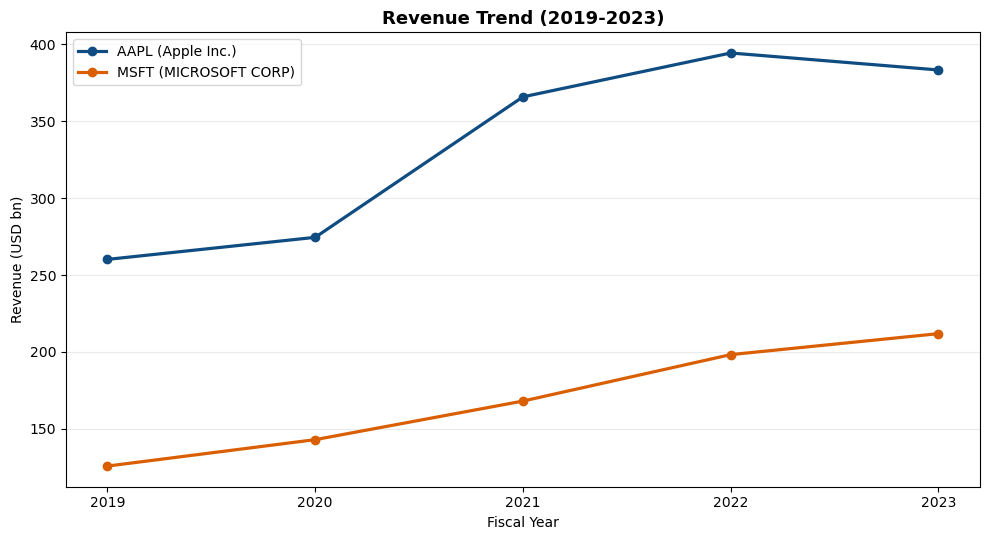

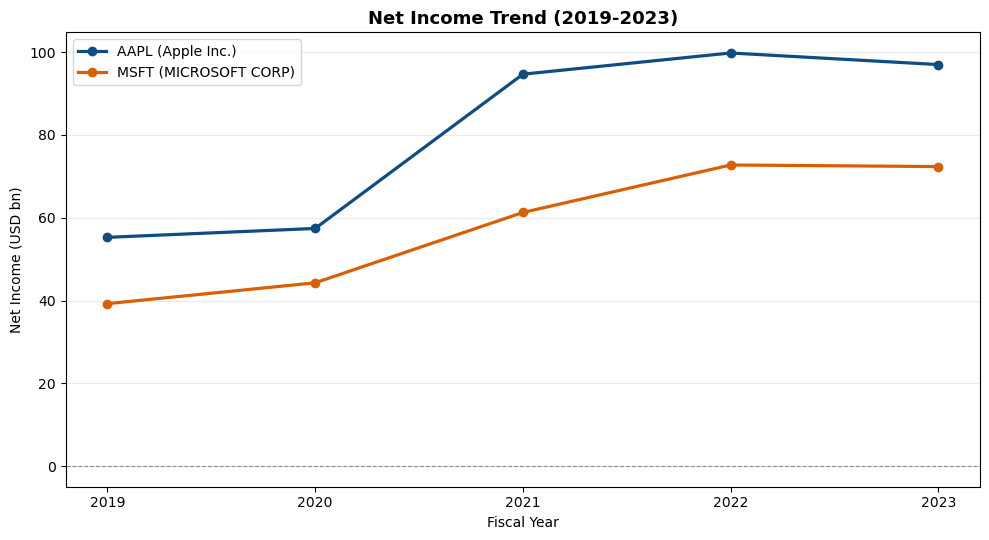

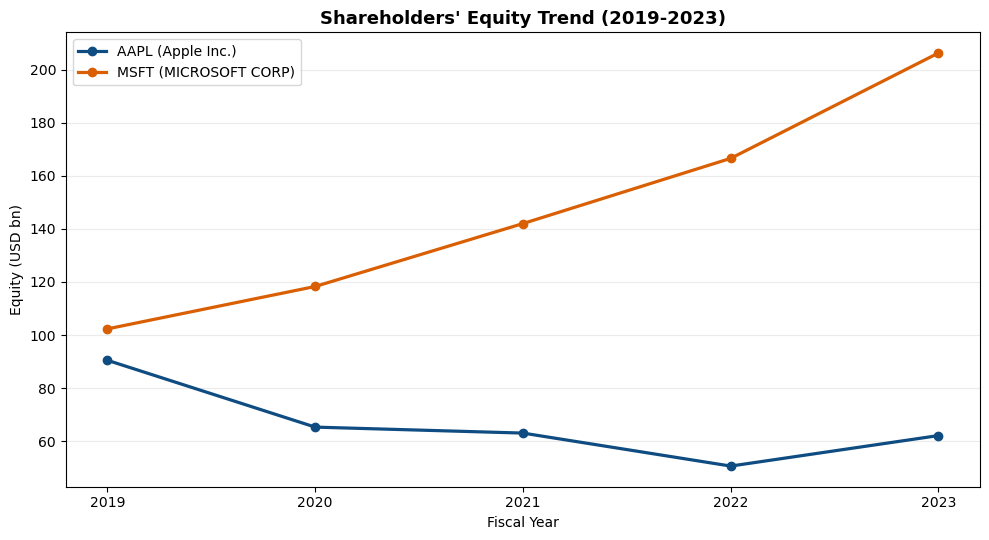

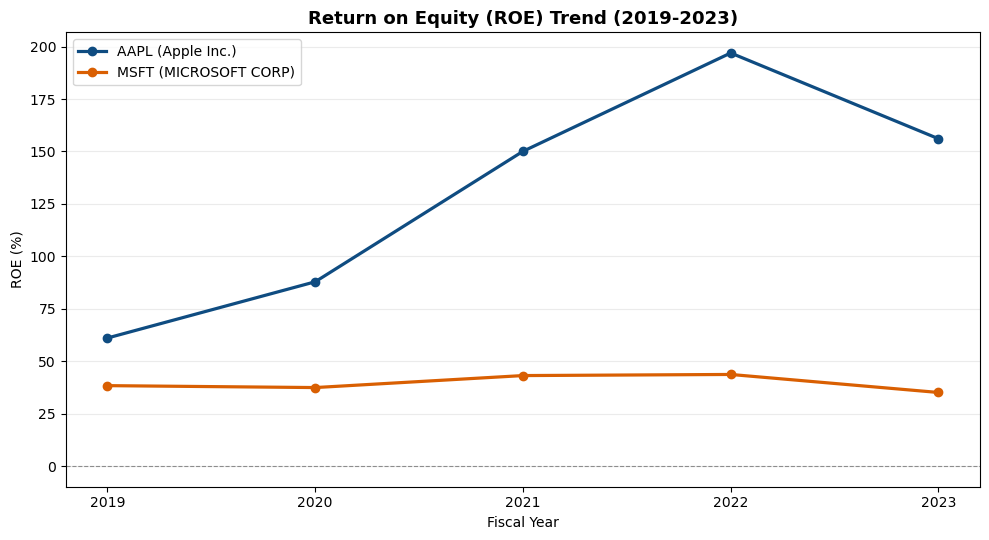

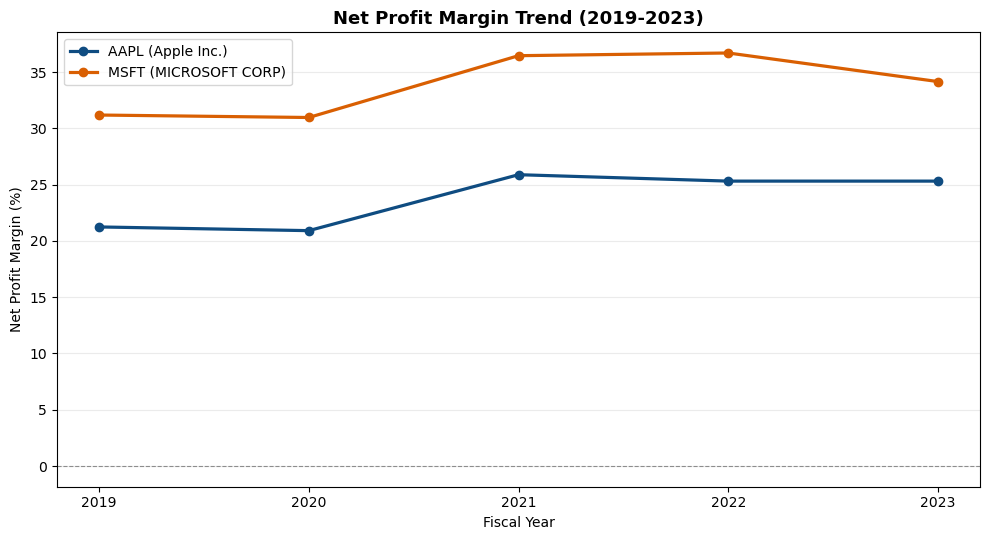

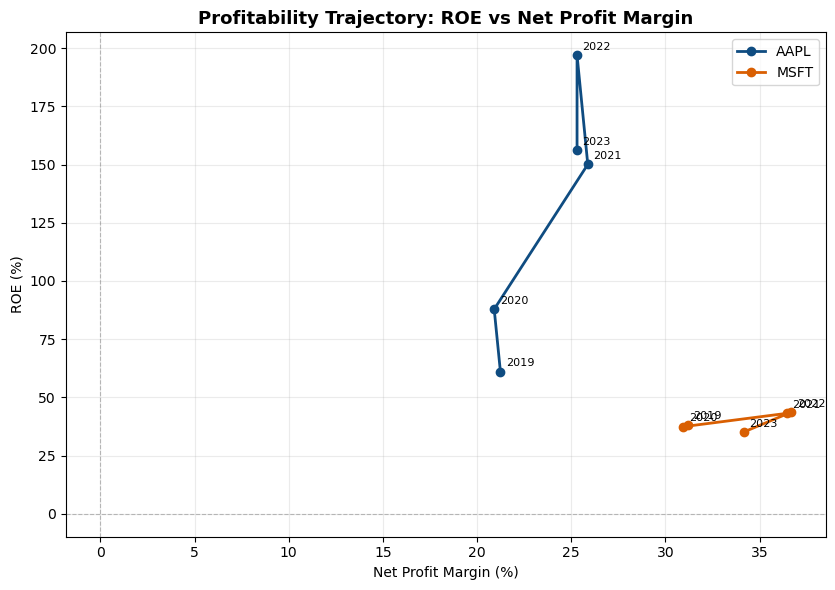

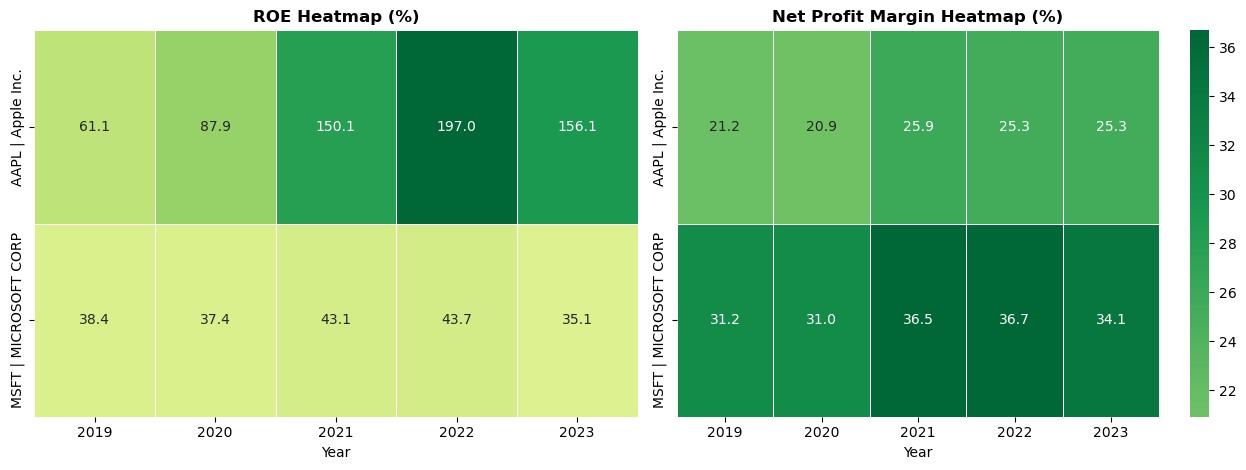

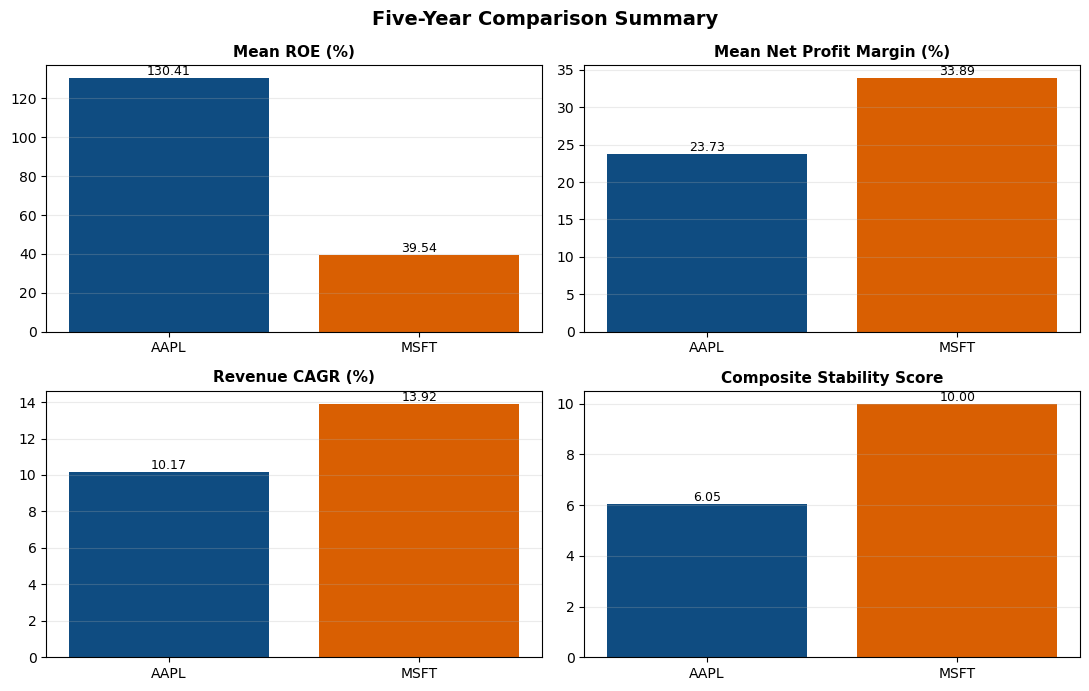


Companies analysed : AAPL vs MSFT
Years covered      : 2019 - 2023
Dataset shape      : (10, 12)
Unique tickers     : 2

--- Data Types ---
Ticker                object
Company               object
Sector                object
Industry              object
Exchange              object
Year                   int64
Revenue_B            float64
Net_Income_B         float64
Equity_B             float64
Assets_B             float64
Net_Profit_Margin    float64
ROE                  float64
dtype: object

--- Missing Values ---
Ticker               0
Company              0
Sector               0
Industry             0
Exchange             0
Year                 0
Revenue_B            0
Net_Income_B         0
Equity_B             0
Assets_B             0
Net_Profit_Margin    0
ROE                  0
dtype: int64

--- Company Profiles ---
Ticker        Company                        Sector                      Industry Exchange
  AAPL     Apple Inc.          Electronic Computers          Electr

In [24]:
# USER INPUT — change only these two ticker symbols.
# Use valid US-listed stock tickers (e.g. 'AAPL', 'MSFT', 'GOOGL', 'AMZN').
TICKER_A = 'AAPL'
TICKER_B = 'MSFT'

result = run_track2_analysis(TICKER_A, TICKER_B)

print(f"\nCompanies analysed : {result['ticker_a']} vs {result['ticker_b']}")
print(f"Years covered      : {result['comparison_df']['Year'].min()} - {result['comparison_df']['Year'].max()}")
print(f"Dataset shape      : {result['comparison_df'].shape}")
print(f"Unique tickers     : {result['comparison_df']['Ticker'].nunique()}")

print('\n--- Data Types ---')
print(result['cleaned_df'].dtypes)

print('\n--- Missing Values ---')
print(result['cleaned_df'].isnull().sum())

print('\n--- Company Profiles ---')
print(result['profiles_df'].to_string(index=False))

print('\n--- Generated Charts ---')
for chart in result['generated_charts']:
    print(chart)

print('\n--- Five-Year Summary Statistics ---')
print(result['summary_df'].sort_values('Composite_Stability', ascending=False).to_string(index=False))

print('\n--- Key Findings ---')
for line in result['findings']:
    print(line)

print('\n--- Exported Files ---')
print(result['comparison_path'])
print(result['summary_path'])


---

## Summary

This notebook provides a complete, reusable tool for comparing the profitability of any two US-listed companies over the five-year period 2019–2023. The analysis is structured across eight sections as follows:

1. **Project Overview** — defines the analytical problem, the intended user, and the data source
2. **Environment Setup** — installs and imports all required libraries; creates output directories and defines global constants
3. **Data Acquisition** — fetches annual financial data from the SEC EDGAR API with an automatic local Excel fallback if the live API is unavailable
4. **Data Cleaning and Preparation** — removes incomplete rows, clips outliers, and computes derived metrics including Net Profit Margin, ROE, Revenue CAGR, and Composite Stability Score
5. **Analysis and Visualisation** — generates eight charts covering revenue, net income, equity, ROE, Net Profit Margin, profitability trajectory, heatmap, and summary bars
6. **Key Findings and Interpretation** — automatically identifies which company leads on profitability and which leads on consistency, with investment-relevant commentary
7. **Export** — saves the full comparison dataset and five-year summary table as CSV files to the `data/` directory
8. **Main Function and Execution** — a single call to `run_track2_analysis(TICKER_A, TICKER_B)` runs the entire pipeline end to end

**Data Source:** U.S. Securities and Exchange Commission (SEC) EDGAR public API. Financial figures are sourced directly from official company filings (Form 10-K for US domestic companies; Form 20-F and 40-F for foreign private issuers listed in the US). A local Excel backup mechanism ensures the notebook remains runnable when the SEC API is unreachable, provided the backup files have been uploaded to the repository.

---
*Data source: SEC EDGAR public API (sec.gov). Accessed April 2026.*
